In [49]:
#Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso, SGDRegressor, LogisticRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing, load_iris
from sklearn.datasets import make_regression

In [50]:
# Set random seed for reproducibility
np.random.seed(42)

#Create my own data (California Housing Data from the web would not load)
X, y = make_regression(n_samples=1000, n_features=8, noise=0.1, random_state=42)

#Use only one feature for simplicity
X = X[:, [0]]

#Split dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

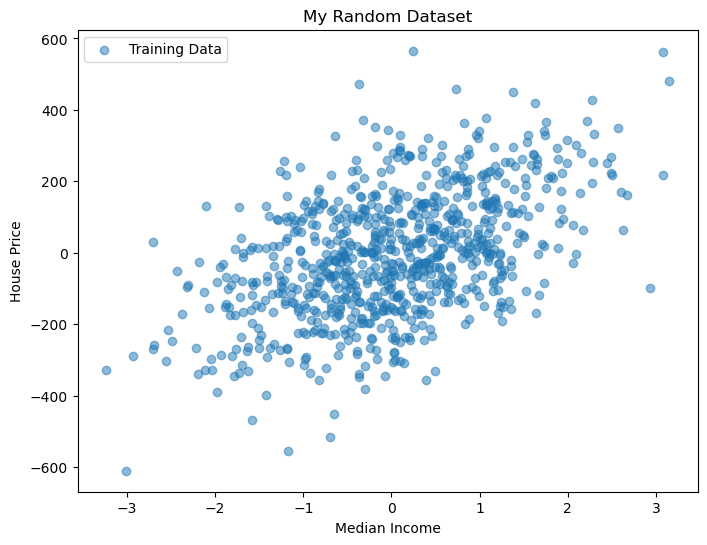

In [51]:
#Plot the data
plt.figure(figsize = (8,6))
plt.scatter(X_train, y_train, alpha=0.5, label = "Training Data")
plt.xlabel("Median Income")
plt.ylabel("House Price")
plt.title("My Random Dataset")
plt.legend()
plt.show()

In [52]:
#Batch Gradient Descent (computers attempt to minimize the loss function in a linear model
#by iteratively moving in the direction of the steepest gradient)
eta = 0.1 #Learning rate
n_epochs = 1000
m = len(X_train)
X_b = np.c_[np.ones((m,1)), X_train] #Add bias term
theta = np.random.randn(2, 1) #Random initialization
y_train_reshaped = y_train.reshape(-1, 1)

for epoch in range (n_epochs):
    gradients = 2 / m * X_b.T @ (X_b @ theta - y_train_reshaped)
    theta -= eta * gradients

In [53]:
print("Final theta values:", theta.ravel()) #print as a flat array

Final theta values: [-4.78177375 80.85635845]


In [54]:
#Stochastic Gradient Descent (picks at random, one of the datapoints and begins to calculate gradients
#going throug the entire dataset, one point at a time
n_epochs = 50
t0, t1 = 5, 50 #Learning schedule hyperparameters

def learning_schedule(t):
    return t0 / (t+ t1)

sgd_theta = np.random.randn(2, 1)
for epoch in range(n_epochs):
    for i in range (m):
        random_index = np.random.randint(m)
        xi = X_b[random_index:random_index+1]
        yi = y_train_reshaped[random_index:random_index+1]
        gradients = 2 * xi.T @ (xi @ sgd_theta - yi)
        eta = learning_schedule(epoch * m + i)
        sgd_theta -= eta * gradients

In [55]:
print("Final theta values:", sgd_theta.ravel()) #print as a flat array

Final theta values: [-1.55685104 77.00702483]


# Interpreting the Output Above
Linear Regression Equation would be y = -1.446 + 77.087(x)

# Polynomial Regression

In [56]:
#In a standard linear regression plot, the line of best fit is flat
#In a polynomial relationship, the line of best fit is curved (x and y don't have a linear relationship) 

In [57]:
#Polynomial Regression
lin_reg = LinearRegression()

poly_features = PolynomialFeatures(degree=2, include_bias = False) #degree=2 means it will square each independent variable
X_poly = poly_features.fit_transform(X_train) #Transforms original X_train to an expanded set that includes the polynomial terms up to degree=2
lin_reg.fit(X_poly, y_train) #fits the data to X_poly and y_train

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [58]:
#Transform the test data using the same polynomial features
X_test_poly = poly_features.transform(X_test)

#Make predictions on test data
y_test_pred = lin_reg.predict(X_test_poly)

#Print first 5 predicted values
print("Predicted Values:", y_test_pred[:5])

#Print first 5 actual values
print("Actual Values:", y_test[:5])

Predicted Values: [-64.5335212   53.03552298  99.39749751  29.49618251 116.27730899]
Actual Values: [298.63509338  14.96215879 215.32908838 -59.00606705   2.94537341]


In [59]:
#Evaluate the model
from sklearn.metrics import mean_squared_error, r2_score

#Compute mean squared error (MSE)
mse = mean_squared_error(y_test, y_test_pred)

#Compute R-squared (R2) score
r2 = r2_score(y_test, y_test_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R2 Score: {r2:.2f}")

Mean Squared Error (MSE): 27063.13
R2 Score: 0.07


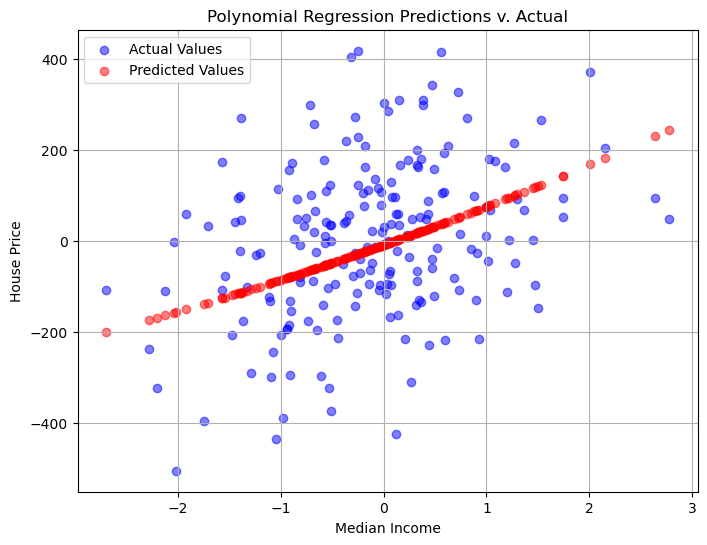

In [60]:
#Plot predictions v. actual values
plt.figure(figsize=(8,6))
plt.scatter(X_test, y_test, color="blue", label= "Actual Values", alpha=0.5)
plt.scatter(X_test, y_test_pred, color="red", label="Predicted Values", alpha=0.5)
plt.xlabel("Median Income")
plt.ylabel("House Price")
plt.title("Polynomial Regression Predictions v. Actual")
plt.legend()
plt.grid(True)
plt.show()

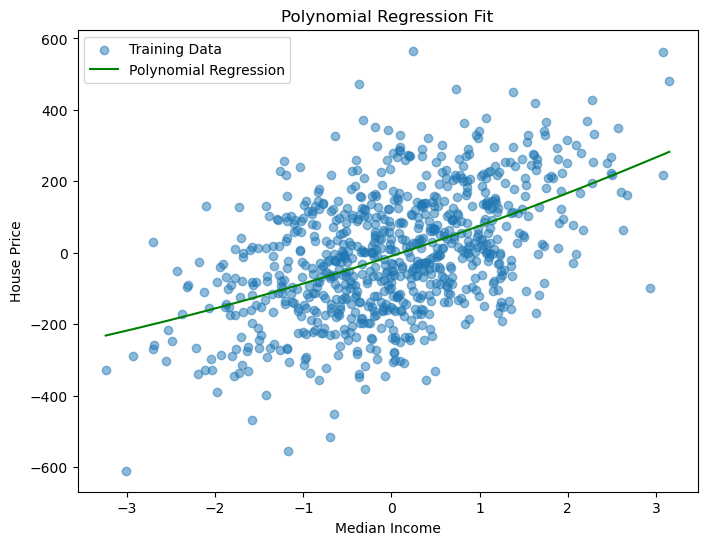

In [61]:
#Plot polynomial regression
X_sorted = np.sort(X_train, axis=0)
y_sorted = lin_reg.predict(poly_features.transform(X_sorted))
plt.figure(figsize=(8,6))
plt.scatter(X_train, y_train, alpha=0.5, label = "Training Data")
plt.plot(X_sorted, y_sorted, color="green", label= "Polynomial Regression")
plt.xlabel("Median Income")
plt.ylabel("House Price")
plt.title("Polynomial Regression Fit")
plt.legend()
plt.show()

# NOTICE THE SLIGHT CURVE IN THE LINE OF BEST FIT

# Ridge Regression

In [62]:
#Ridge Regression (L2 Regularization)
ridge_reg = Ridge(alpha=1, solver="cholesky")
ridge_reg.fit(X_train, y_train)

#Ridge regression is best when there are problems with multi-colinearity amongst your independent variables
#Multi-colinearity means there is correlation between multiple independent variables
#Ridge Regression handles multi-colinearity by adding a mathematical penalty to the loss function
#to try and minimize the presence of large coefficients and their influence over the outcome
#We control this through the use of "alpha" --> the lower the alpha, the more it operates like linear regression
#The higher the alpha, the more it shrinks the coefficients to try and mitigate colinearity
#The solver "cholesky" is used for small-to-medium sized datasets

,alpha,1
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'cholesky'
,positive,False
,random_state,None


In [63]:
#Make predictions on the test set
y_test_pred = ridge_reg.predict(X_test)

#Print first 5 predicted values
print("Predicted Values:", y_test_pred[:5])

#Print first 5 actual values
print("Actual Values:", y_test[:5])

Predicted Values: [-62.23004495  55.18523829  97.60320742  32.89134699 112.5954058 ]
Actual Values: [298.63509338  14.96215879 215.32908838 -59.00606705   2.94537341]


In [64]:
#Evaluate the model using MSE and r2
mse = mean_squared_error(y_test, y_test_pred)

r2 = r2_score(y_test, y_test_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R2 Score: {r2:.2f}")

Mean Squared Error (MSE): 26879.11
R2 Score: 0.08


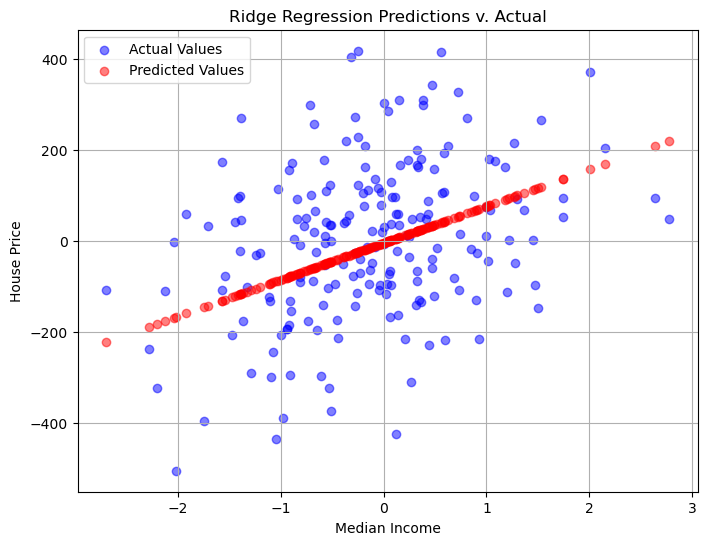

In [65]:
#Plot predictions v. actual values
plt.figure(figsize=(8,6))
plt.scatter(X_test, y_test, color="blue", label= "Actual Values", alpha=0.5)
plt.scatter(X_test, y_test_pred, color="red", label="Predicted Values", alpha=0.5)
plt.xlabel("Median Income")
plt.ylabel("House Price")
plt.title("Ridge Regression Predictions v. Actual")
plt.legend()
plt.grid(True)
plt.show()

# Key Scenarios for Using Ridge Regression

1. Highly coorelated features (multicollinearity)
2. To reduce overfitting in high-dimensional datasets
3. When you have too many features relative to the number of samples

# Lasso Regression


In [66]:
#Lasso Regression (L1 Regularization)
lasso_reg = Lasso(alpha=0.1)
lasso_reg.fit(X_train, y_train)

#We use Lasso when we have lots of variables, and we need to get fewer variables
#Lasso assigs a zero-value to a particular value to effectively stop a colinearity issue; therefore, reducing the # of variables

,alpha,0.1
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [67]:
#Make predictions on the test set
y_test_pred = lasso_reg.predict(X_test)

#Print first 5 predicted values
print("Predicted Values:", y_test_pred[:5])

#Print first 5 actual values
print("Actual Values:", y_test[:5])

Predicted Values: [-62.23066293  55.18586002  97.60427702  32.89173334 112.5966337 ]
Actual Values: [298.63509338  14.96215879 215.32908838 -59.00606705   2.94537341]


In [68]:
#Evaluate the model using MSE and R2
mse = mean_squared_error(y_test, y_test_pred)

r2 = r2_score(y_test, y_test_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R2 Score: {r2:.2f}")

Mean Squared Error (MSE): 26879.14
R2 Score: 0.08


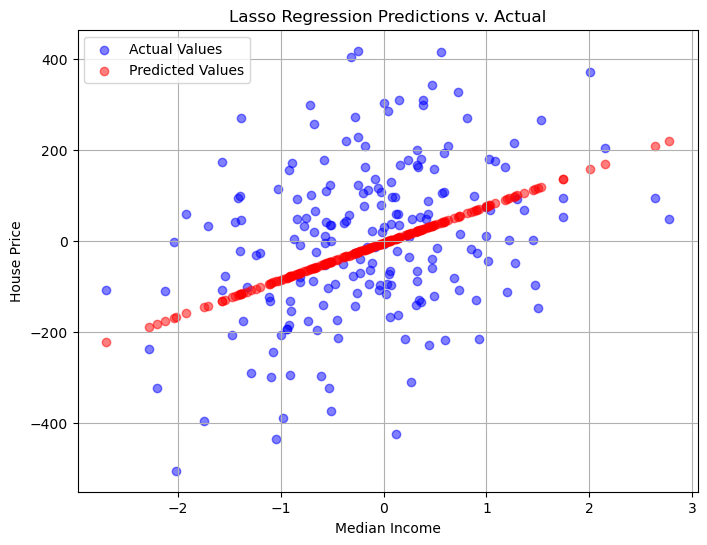

In [69]:
#Plot predictions v. actual values
plt.figure(figsize=(8,6))
plt.scatter(X_test, y_test, color="blue", label= "Actual Values", alpha=0.5)
plt.scatter(X_test, y_test_pred, color="red", label="Predicted Values", alpha=0.5)
plt.xlabel("Median Income")
plt.ylabel("House Price")
plt.title("Lasso Regression Predictions v. Actual")
plt.legend()
plt.grid(True)
plt.show()

# Key Scenarios for Using Lasso Regression
1. When you want feature selection (Automatic Variable Reduction)
2. When you have a large number of Features (High-Dimensional Data)
3. When you need to reduce overfitting